# Heart Disease Analysis - Visualization, Preprocessing & Encoding

In [121]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

---
# PART 1: Data Inspection & Understanding
---

In [122]:
data = pd.read_csv(r"C:\Users\RAWDA AMR\Downloads\Heart_disease.csv")
data.head()

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3,30,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0,0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,NaN
2,No,NaN,Yes,No,No,20,30,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0,0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28,0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [123]:
data.info()
print("\nDataset shape:", data.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16859 entries, 0 to 16858
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   HeartDisease      16859 non-null  object 
 1   BMI               15255 non-null  float64
 2   Smoking           16859 non-null  object 
 3   AlcoholDrinking   16859 non-null  object 
 4   Stroke            16859 non-null  object 
 5   PhysicalHealth    16859 non-null  int64  
 6   MentalHealth      16859 non-null  int64  
 7   DiffWalking       16854 non-null  object 
 8   Sex               16859 non-null  object 
 9   AgeCategory       16859 non-null  object 
 10  Race              16859 non-null  object 
 11  Diabetic          16859 non-null  object 
 12  PhysicalActivity  16859 non-null  object 
 13  GenHealth         16859 non-null  object 
 14  SleepTime         16355 non-null  float64
 15  Asthma            16859 non-null  object 
 16  KidneyDisease     16859 non-null  object

In [124]:
missing = data.isnull().sum()
missing[missing > 0]

BMI            1604
DiffWalking       5
SleepTime       504
SkinCancer     1164
dtype: int64

## Data Types & Unique Values

In [125]:
print("Data types:")
print(data.dtypes)

Data types:
HeartDisease         object
BMI                 float64
Smoking              object
AlcoholDrinking      object
Stroke               object
PhysicalHealth        int64
MentalHealth          int64
DiffWalking          object
Sex                  object
AgeCategory          object
Race                 object
Diabetic             object
PhysicalActivity     object
GenHealth            object
SleepTime           float64
Asthma               object
KidneyDisease        object
SkinCancer           object
dtype: object


In [126]:
print("Unique values per column:")
data.nunique().sort_values()

Unique values per column:


HeartDisease           2
Smoking                2
AlcoholDrinking        2
Stroke                 2
DiffWalking            2
Asthma                 2
PhysicalActivity       2
Sex                    2
SkinCancer             2
KidneyDisease          2
Diabetic               4
GenHealth              5
Race                   6
AgeCategory           13
SleepTime             20
MentalHealth          29
PhysicalHealth        31
BMI                 1726
dtype: int64

## Feature Classification

### Decision Questions:

**Q: Which features look numeric but should be treated as categorical?**
  - SleepTIme

**Q: Which features look categorical but contain ordering?**
- GenHealth: Has ordering (Poor < Fair < Good < Very good < Excellent)
- AgeCategory: Has ordering (18-24 < 25-29 < ... < 80 or older)

**Q: Why is misclassifying a feature dangerous?**
- If we treat AgeCategory as nominal (no order), we lose important age progression information
- If we treat Race as ordinal (with order), we create false relationships between races
- Wrong classification leads to wrong encoding, which leads to wrong model predictions

In [127]:
Target_col = "HeartDisease"

Numeric_cols = ["BMI", "PhysicalHealth", "MentalHealth", "SleepTime"]
Ordinal_cols = ["GenHealth", "AgeCategory"]
Nominal_cols = ["Race", "Diabetic"]
Binary_cols = [
    "Smoking", "AlcoholDrinking", "Stroke", "DiffWalking",
    "PhysicalActivity", "Asthma", "KidneyDisease", "SkinCancer", "Sex"
]

print("Feature Classification:")
print(f"Numeric: {Numeric_cols}")
print(f"Ordinal: {Ordinal_cols}")
print(f"Nominal: {Nominal_cols}")
print(f"Binary: {Binary_cols}")

Feature Classification:
Numeric: ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']
Ordinal: ['GenHealth', 'AgeCategory']
Nominal: ['Race', 'Diabetic']
Binary: ['Smoking', 'AlcoholDrinking', 'Stroke', 'DiffWalking', 'PhysicalActivity', 'Asthma', 'KidneyDisease', 'SkinCancer', 'Sex']


---
# PART 2: Visualization & Insights
---

## Target Variable Visualization

**Q: Choose ONE - Countplot, Pie chart, or Histogram?**
   - Countplot
Why:
- Countplot clearly shows the actual numbers
- Pie chart is harder to compare proportions accurately
- Histogram is for continuous data, not categorical

**Q: Is the dataset balanced or imbalanced?**
  - Imbalanced

**Q: How does this affect model choice and evaluation metrics?**
- Model choice: Need to use stratified sampling and possibly class weights, may predict 'no' for all cases
- Evaluation metrics: Accuracy is misleading. Use Precision, Recall, F1-Score, and ROC-AUC instead

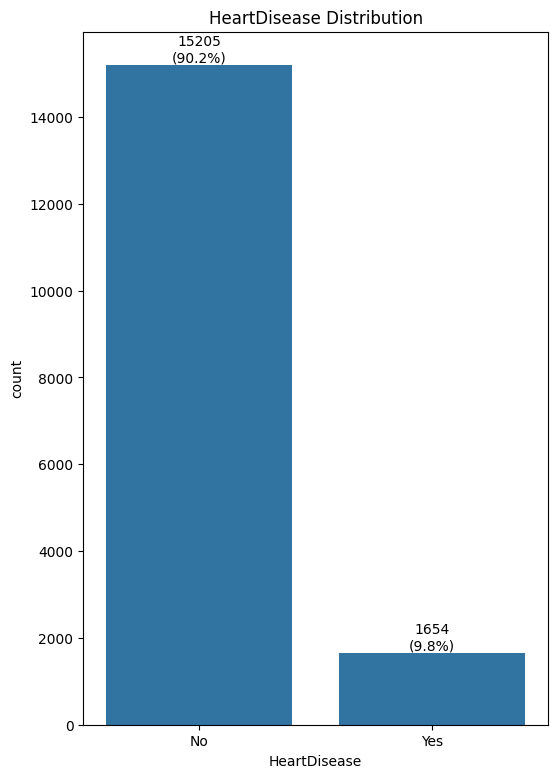

HeartDisease
No     90.189216
Yes     9.810784
Name: proportion, dtype: float64

Dataset is imbalanced (around 90% No, 10% Yes)


In [128]:
plt.figure(figsize=(6, 9))
ax = sns.countplot(data=data, x=Target_col, order=data[Target_col].value_counts().index)

total = len(data)
for p in ax.patches:
    count = int(p.get_height())
    percentage = f'{100 * count / total:.1f}%'
    ax.annotate(f'{count}\n({percentage})', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title("HeartDisease Distribution")
plt.show()

print(data[Target_col].value_counts(normalize=True) * 100)
print("\nDataset is imbalanced (around 90% No, 10% Yes)")

## Numerical Feature Distribution

**Q: Choose Histogram, Boxplot, or Violin?**
   - Boxplot

Why:
- Boxplot clearly shows outliers
- Shows median and quartiles
- Helps decide if we need robust scaling

# Skewness:
 - BMI: 
 - PhysicalHealth, MentalHealth: High

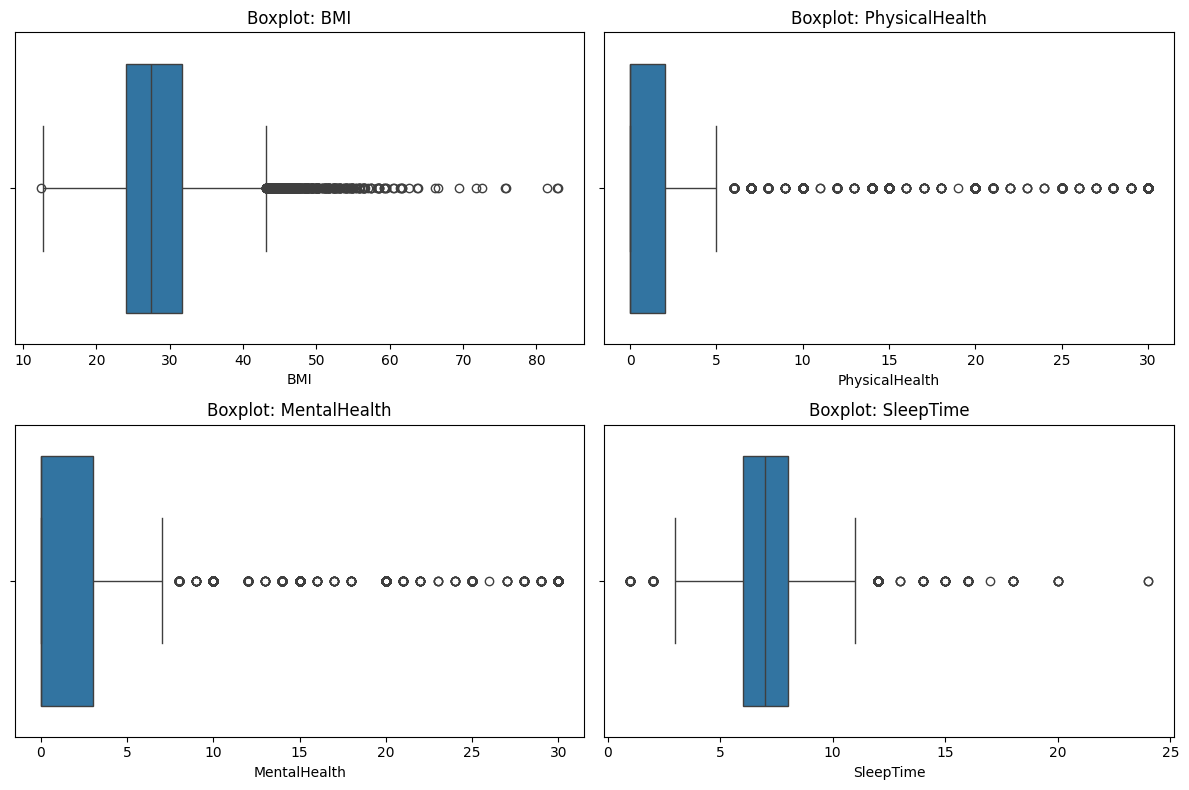

In [129]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for idx, col in enumerate(Numeric_cols):
    sns.boxplot(data=data, x=col, ax=axes[idx])
    axes[idx].set_title(f"Boxplot: {col}")

plt.tight_layout()
plt.show()

In [130]:
for col in Numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = data[(data[col] < Q1 - 1.5*IQR) | (data[col] > Q3 + 1.5*IQR)][col]
    outlier_pct = (len(outliers) / len(data.dropna(subset=[col]))) * 100
    skewness = data[col].skew()
    
    print(f"{col}:")
    print(f"  Outliers: {len(outliers)} ({outlier_pct:.1f}%)")
    print(f"  Skewness: {skewness:.2f}")
    
    if outlier_pct > 5:
        print(f"Use RobustScaler (resistant to outliers)")
    else:
        print(f"StandardScaler is fine")
    print()

BMI:
  Outliers: 424 (2.8%)
  Skewness: 1.27
StandardScaler is fine

PhysicalHealth:
  Outliers: 2850 (16.9%)
  Skewness: 2.36
Use RobustScaler (resistant to outliers)

MentalHealth:
  Outliers: 2674 (15.9%)
  Skewness: 2.34
Use RobustScaler (resistant to outliers)

SleepTime:
  Outliers: 293 (1.8%)
  Skewness: 0.88
StandardScaler is fine



## Categorical Feature Distribution

**Q: Choose Countplot or Bar chart?**
   - Countplot

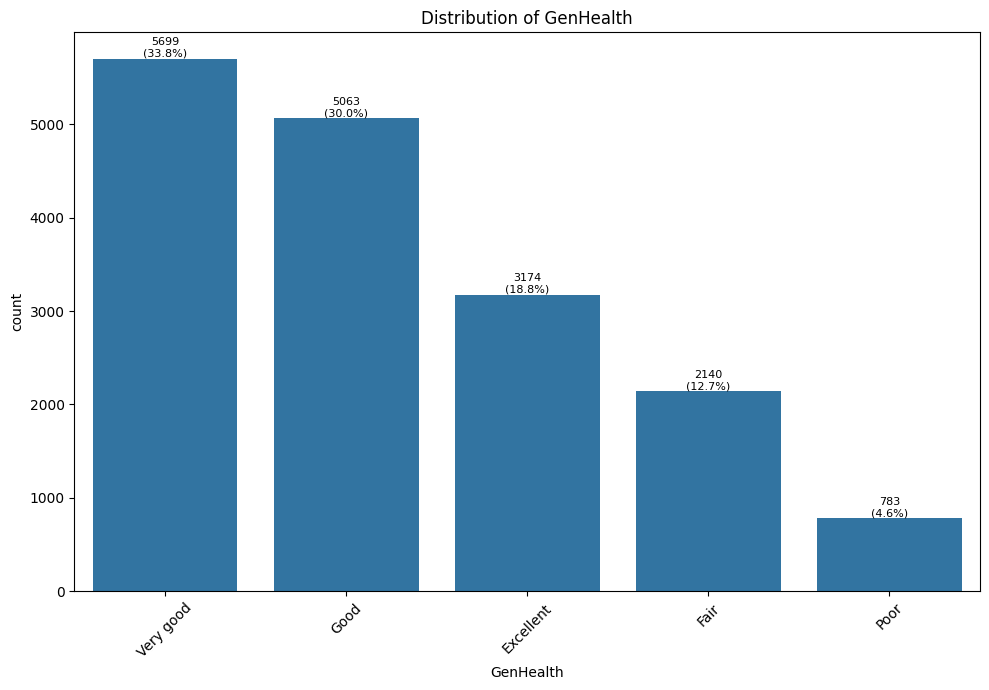

GenHealth:
  Dominant category: Very good
  Imbalance: Acceptable


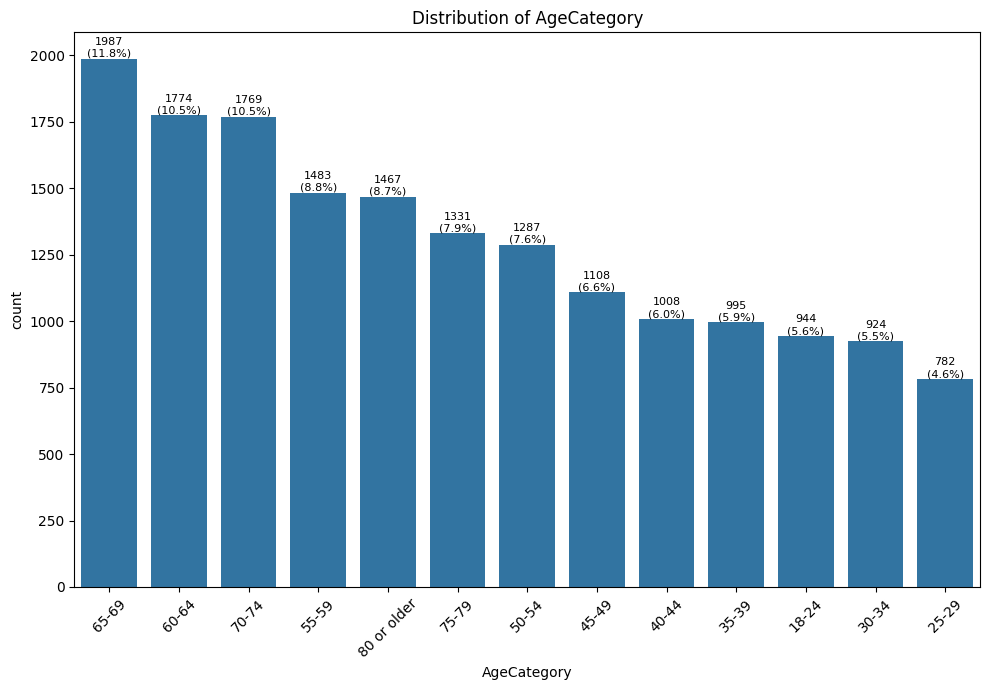

AgeCategory:
  Dominant category: 65-69
  Imbalance: Acceptable


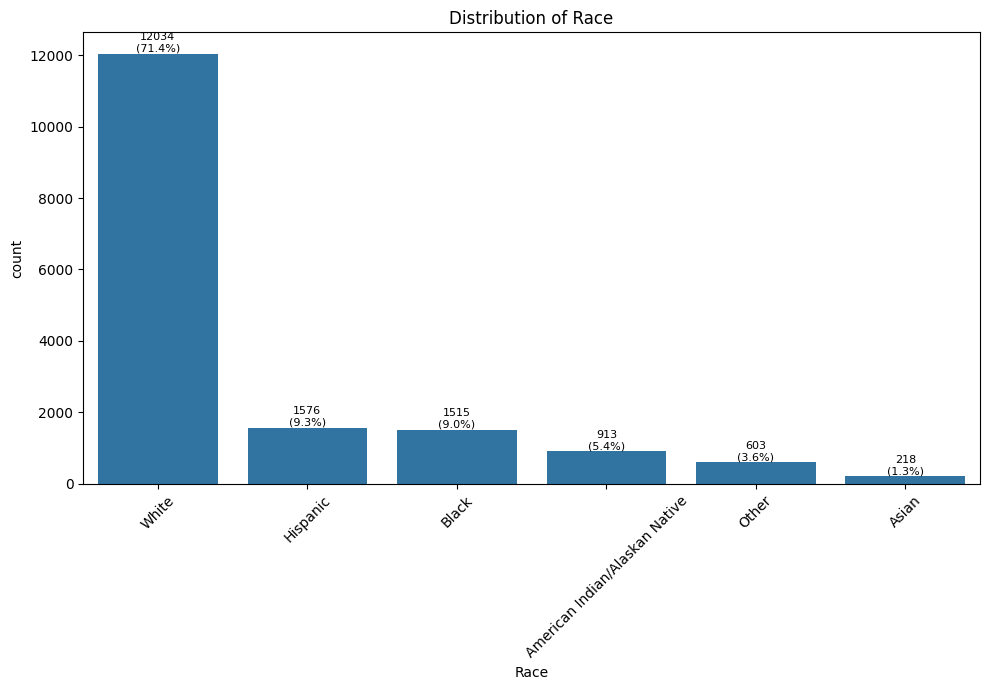

Race:
  Dominant category: White
  Imbalance: Moderate


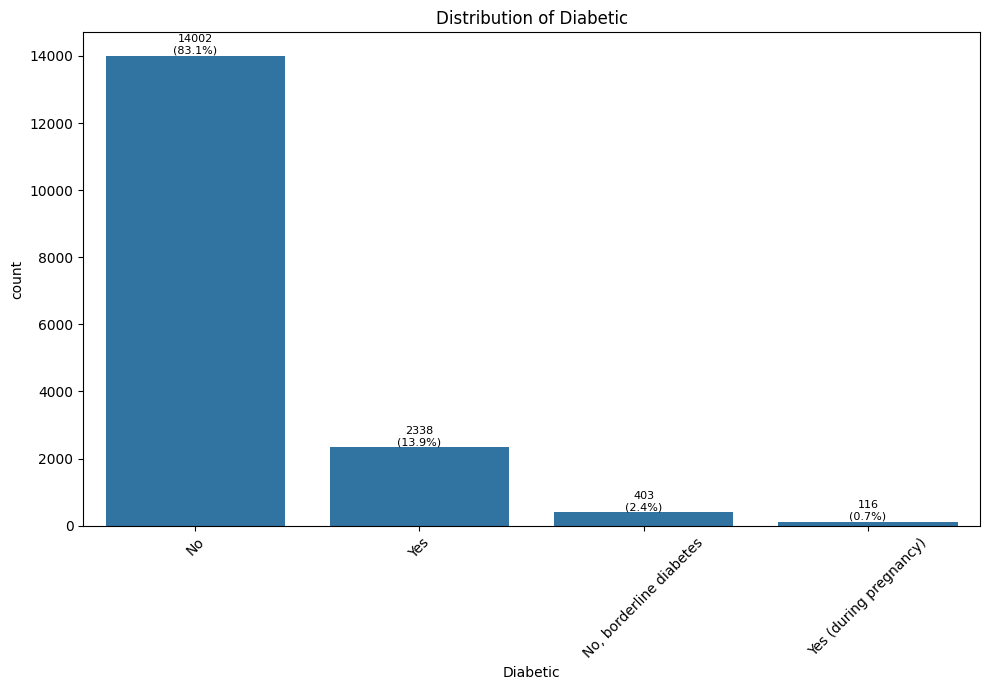

Diabetic:
  Dominant category: No
  Imbalance: Severe


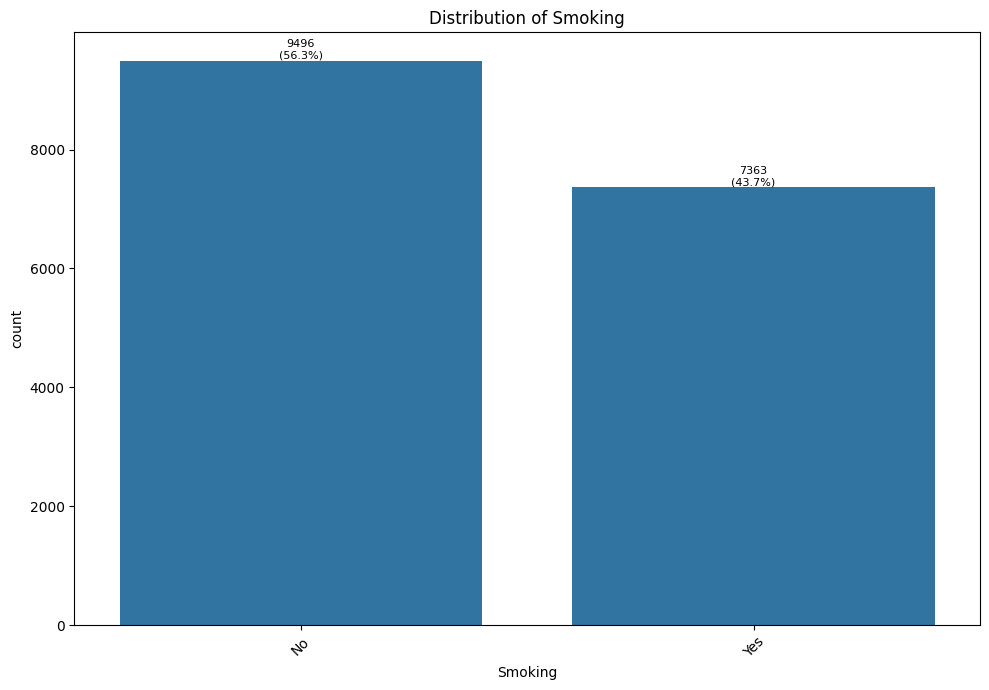

Smoking:
  Dominant category: No
  Imbalance: Acceptable


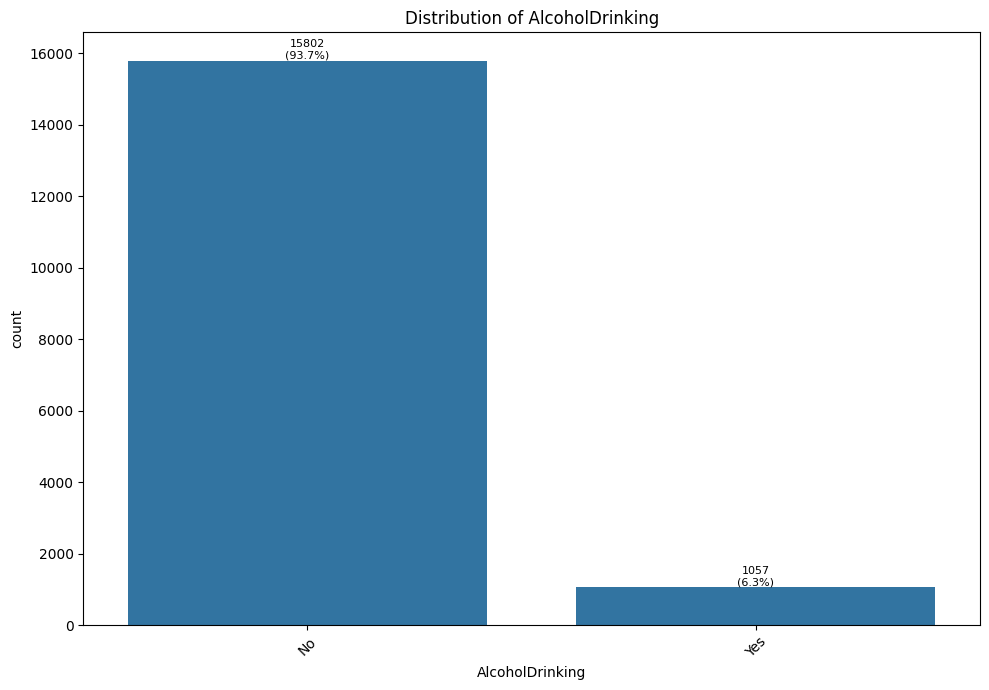

AlcoholDrinking:
  Dominant category: No
  Imbalance: Severe


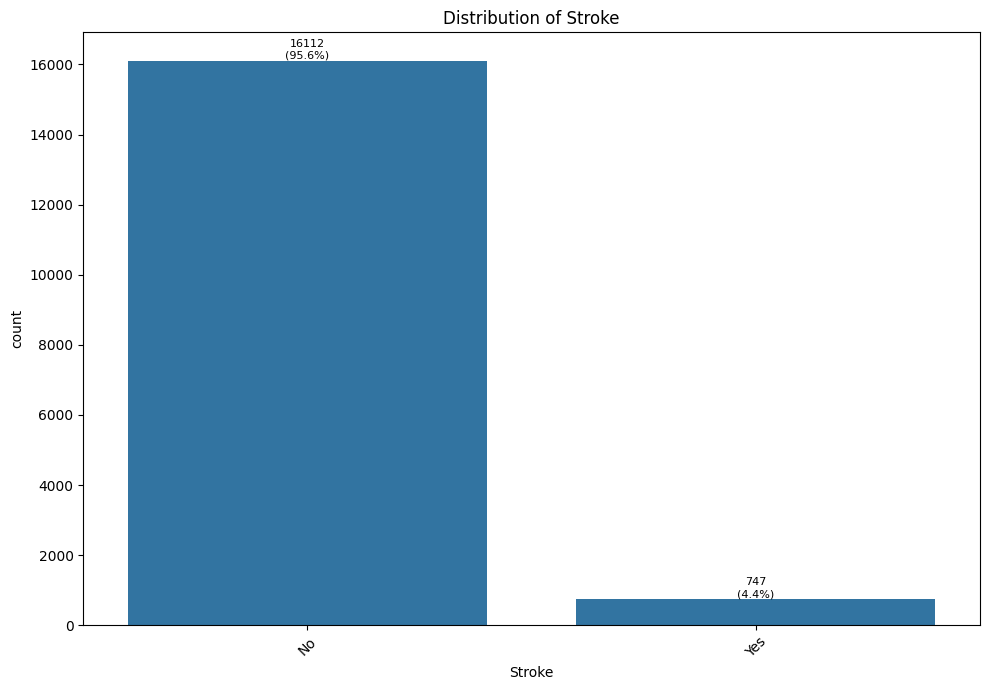

Stroke:
  Dominant category: No
  Imbalance: Severe


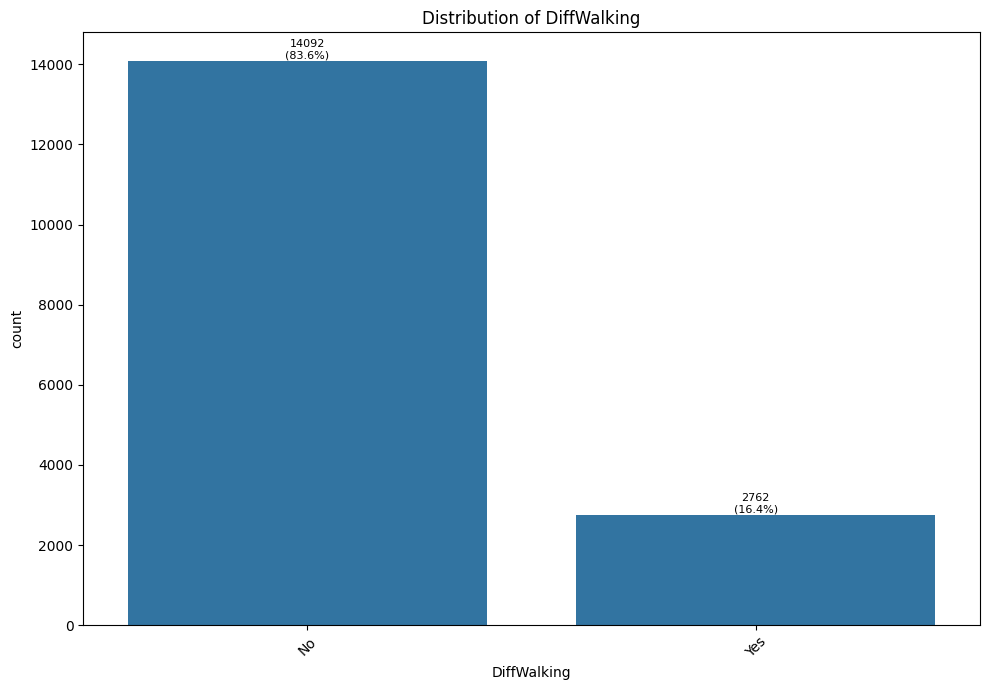

DiffWalking:
  Dominant category: No
  Imbalance: Severe


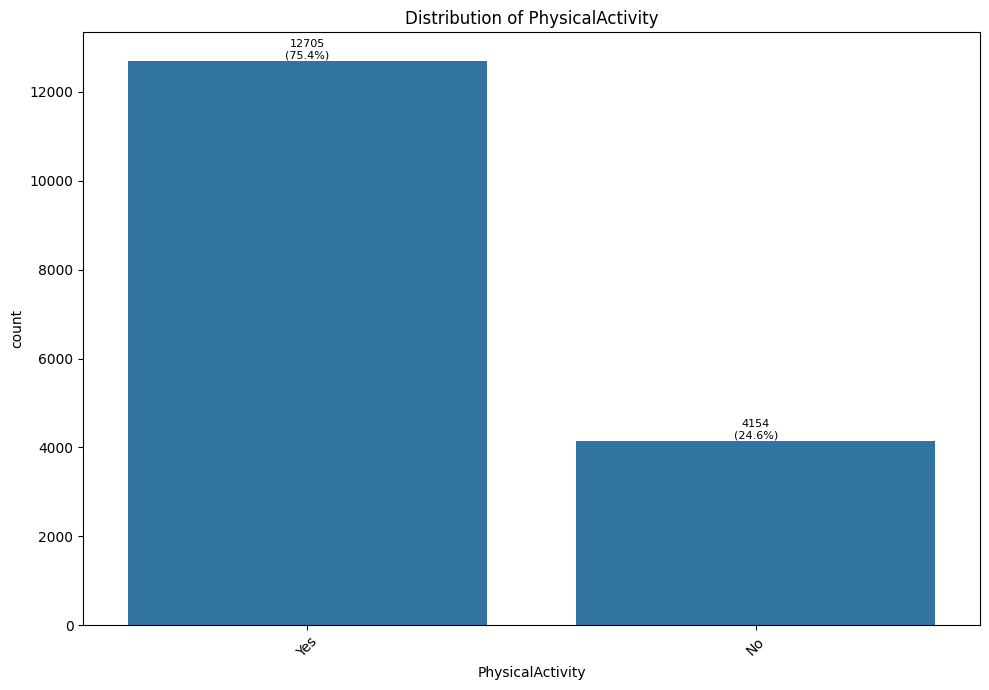

PhysicalActivity:
  Dominant category: Yes
  Imbalance: Moderate


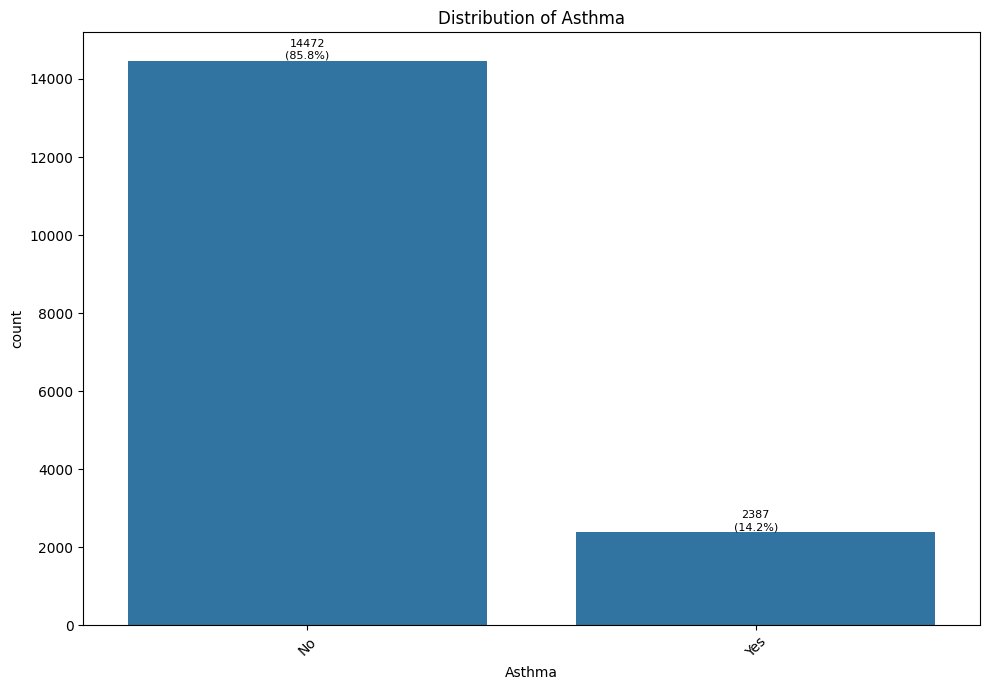

Asthma:
  Dominant category: No
  Imbalance: Severe


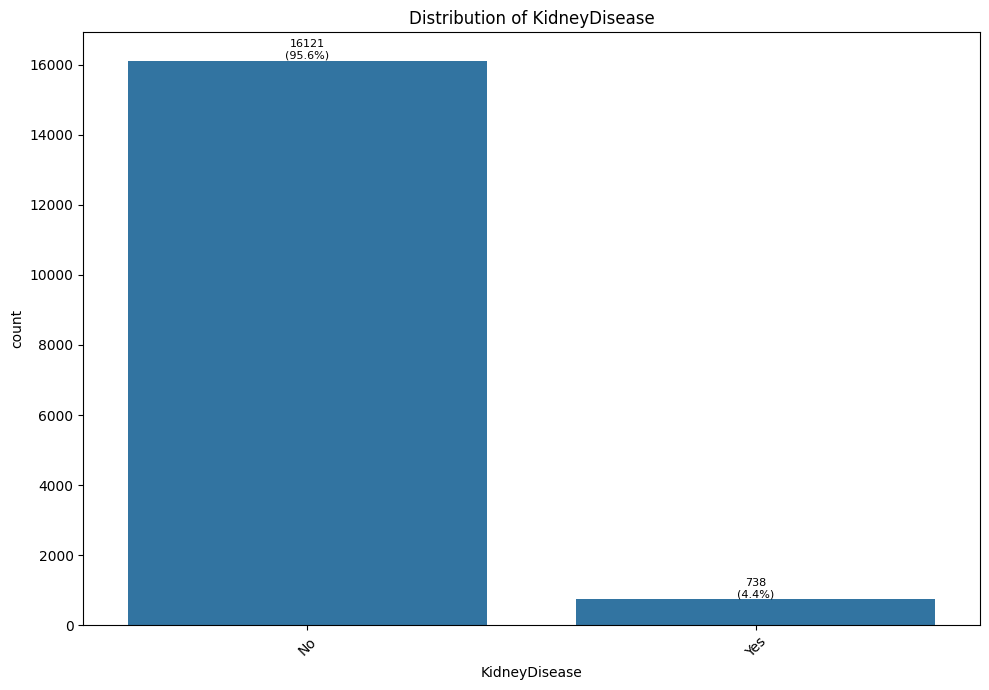

KidneyDisease:
  Dominant category: No
  Imbalance: Severe


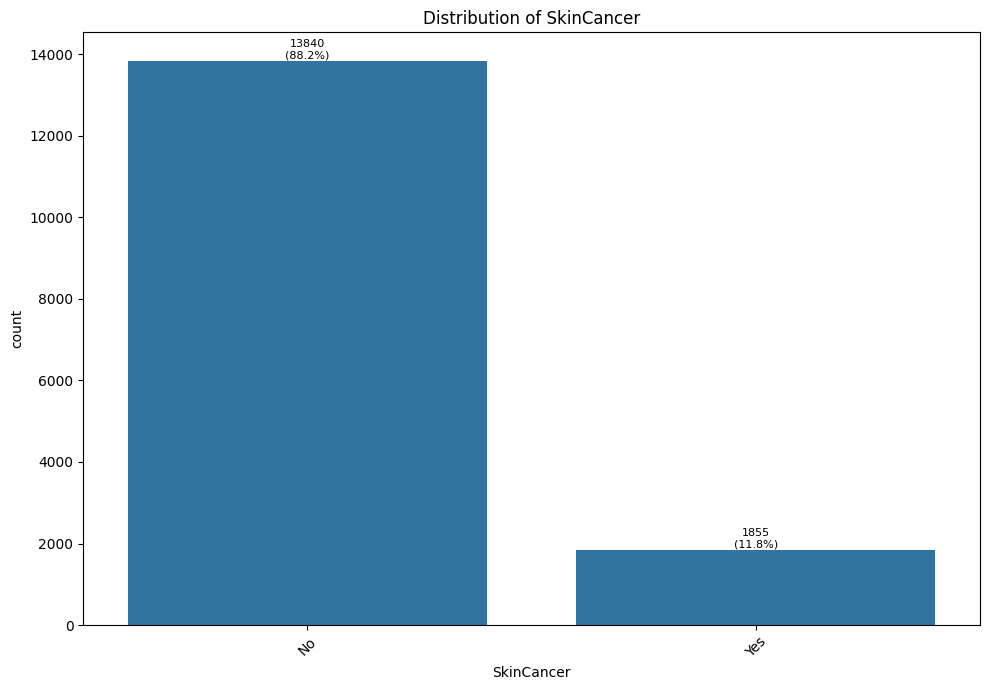

SkinCancer:
  Dominant category: No
  Imbalance: Severe


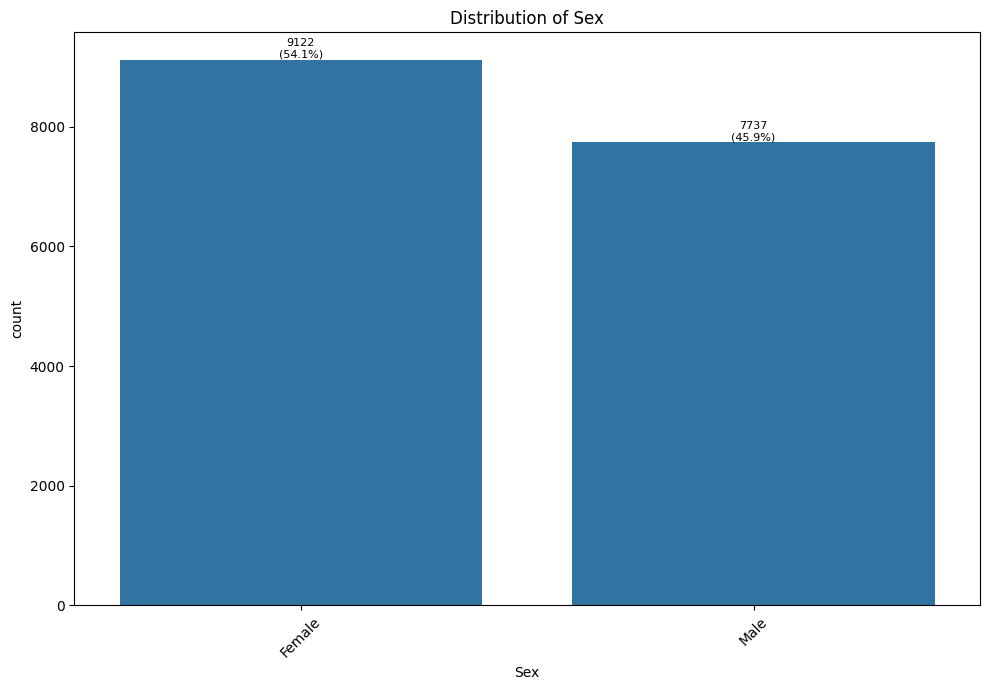

Sex:
  Dominant category: Female
  Imbalance: Acceptable


In [131]:
categorical_cols = Ordinal_cols + Nominal_cols + Binary_cols

for col in categorical_cols:
    plt.figure(figsize=(10, 7))
    order = data[col].value_counts().index
    ax = sns.countplot(data=data, x=col, order=order)
    
    total = len(data.dropna(subset=[col]))
    for p in ax.patches:
        count = int(p.get_height())
        percentage = f'{100 * count / total:.1f}%'
        ax.annotate(f'{count}\n({percentage})', 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom', fontsize=8)
    
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    value_counts = data[col].value_counts(normalize=True) * 100
    dominant = value_counts.iloc[0]
    
    print(f"{col}:")
    print(f"  Dominant category: {value_counts.index[0]}")
    if dominant > 80:
        print(f"  Imbalance: Severe")
    elif dominant > 60:
        print(f"  Imbalance: Moderate")
    else:
        print(f"  Imbalance: Acceptable")


## Feature vs Target Analysis (CRITICAL)

### A) Categorical vs Target

**Q: Choose Stacked bar chart OR Grouped bar chart?**
]  - Stacked bar chart

Why:
- Shows proportions clearly (normalized to 100%)
- Easy to compare percentages across categories
- Better for imbalanced data

For each feature, we need to explain:
- Which category shows higher risk? AgeCategoty
- Is the relationship clear or noisy? Clear
- Does the feature seem predictive? yes

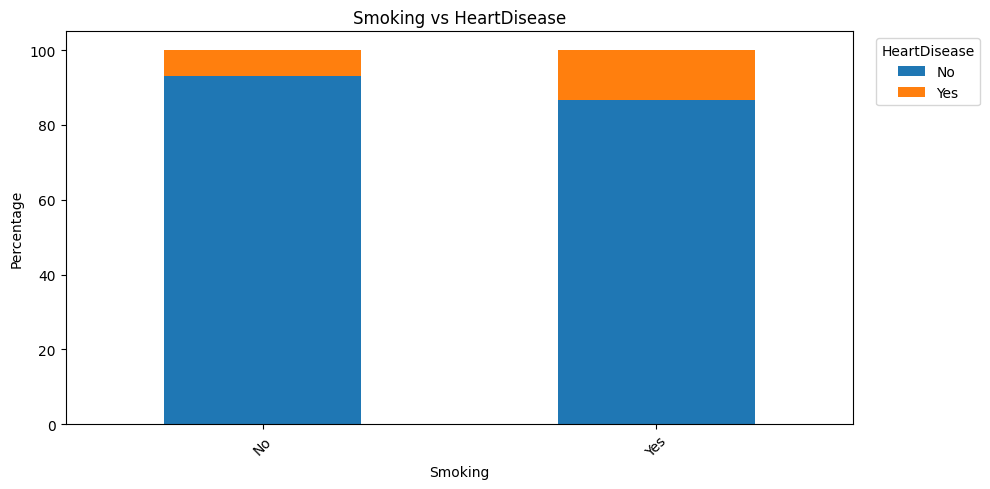


Analysis of Smoking with HeartDisease:
  Yes: 13.35%
  No: 7.07%

Difference: 6.28%
Relationship: Moderate
--------------------------------------------------


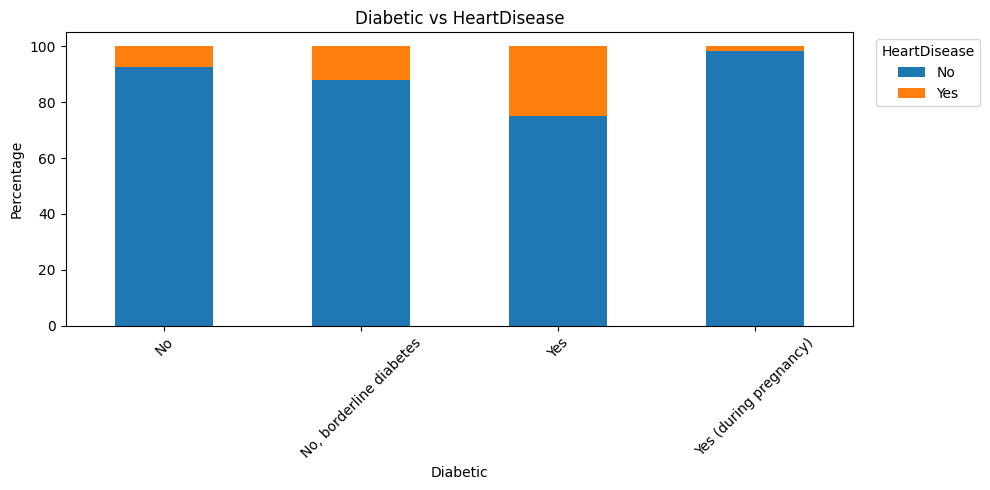


Analysis of Diabetic with HeartDisease:
  Yes: 25.02%
  No, borderline diabetes: 12.16%
  No: 7.27%
  Yes (during pregnancy): 1.72%

Difference: 23.30%
Relationship: Strong (predictive feature)
--------------------------------------------------


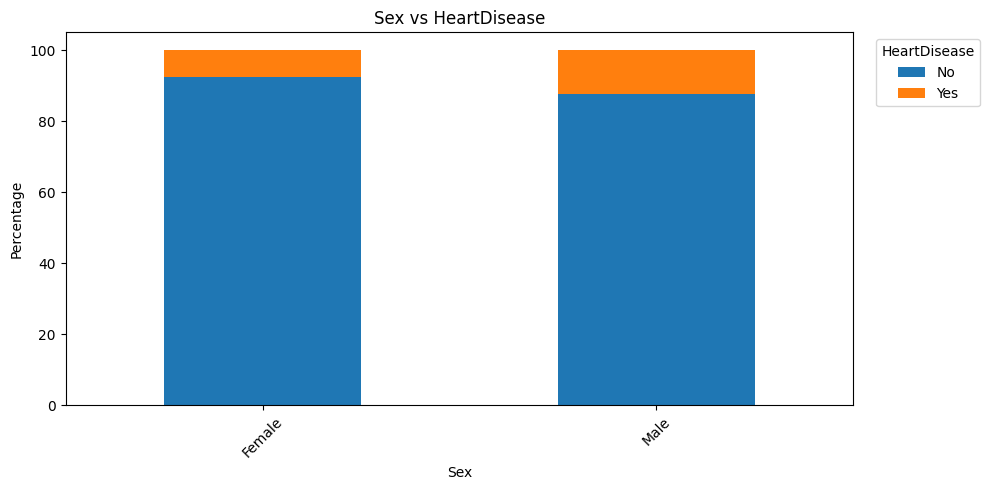


Analysis of Sex with HeartDisease:
  Male: 12.33%
  Female: 7.67%

Difference: 4.66%
Relationship: Weak
--------------------------------------------------


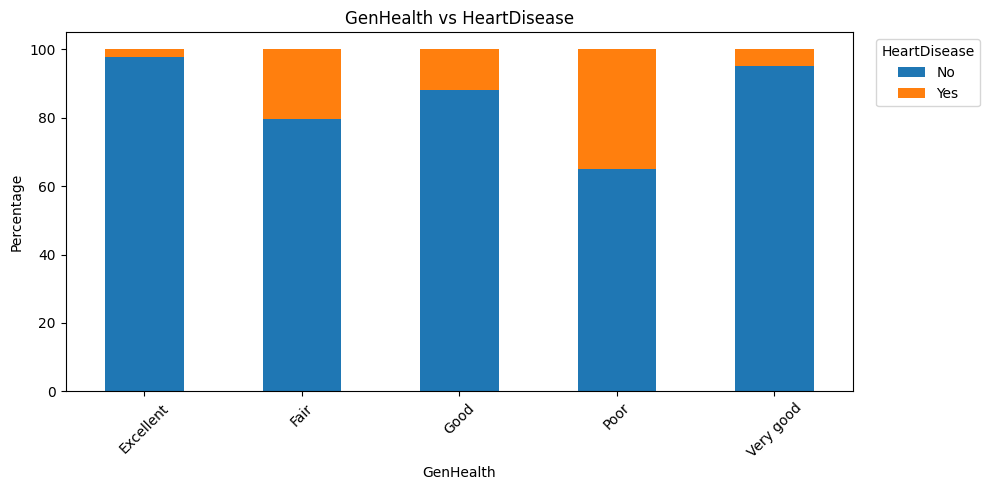


Analysis of GenHealth with HeartDisease:
  Poor: 34.87%
  Fair: 20.37%
  Good: 11.85%
  Very good: 4.83%
  Excellent: 2.21%

Difference: 32.66%
Relationship: Strong (predictive feature)
--------------------------------------------------


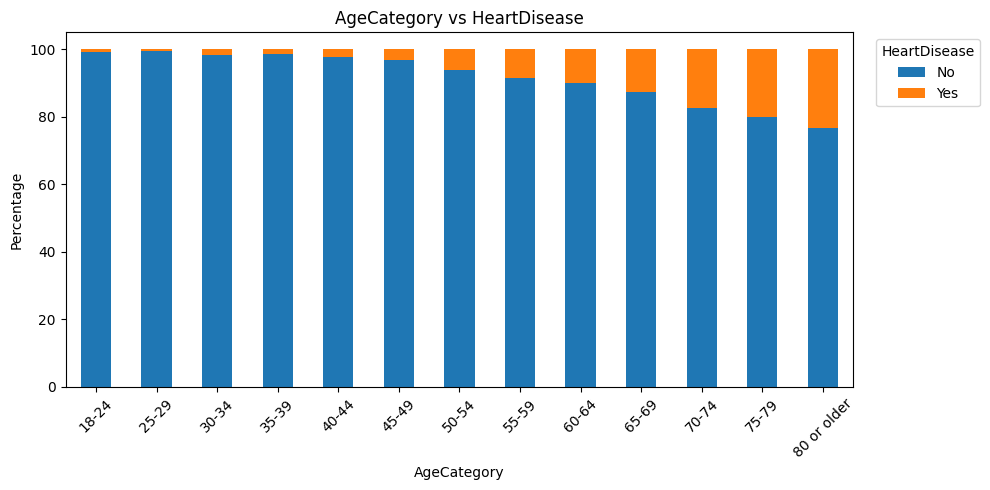


Analysis of AgeCategory with HeartDisease:
  80 or older: 23.38%
  75-79: 20.14%
  70-74: 17.47%
  65-69: 12.68%
  60-64: 9.86%
  55-59: 8.56%
  50-54: 6.22%
  45-49: 3.16%
  40-44: 2.38%
  30-34: 1.62%
  35-39: 1.31%
  18-24: 0.85%
  25-29: 0.64%

Difference: 22.74%
Relationship: Strong (predictive feature)
--------------------------------------------------


In [132]:
important_cats = ["Smoking", "Diabetic", "Sex", "GenHealth", "AgeCategory"]

for col in important_cats:
    ct = pd.crosstab(data[col], data[Target_col], normalize="index") * 100
    
    ct.plot(kind="bar", stacked=True, figsize=(10, 5))
    plt.title(f'{col} vs {Target_col}')
    plt.ylabel('Percentage')
    plt.xticks(rotation=45)
    plt.legend(title=Target_col, bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()
    
    print(f"\nAnalysis of {col} with HeartDisease:")
    yes_pct = ct['Yes'].sort_values(ascending=False)
    for category, pct in yes_pct.items():
        print(f"  {category}: {pct:.2f}%")
    
    range_diff = yes_pct.max() - yes_pct.min()
    print(f"\nDifference: {range_diff:.2f}%")
    
    if range_diff > 10:
        print(f"Relationship: Strong (predictive feature)")
    elif range_diff > 5:
        print(f"Relationship: Moderate")
    else:
        print(f"Relationship: Weak")
    print("-" * 50)

### B) Numerical vs Target

**Q: Choose Boxplot by target OR Violin plot by target?**
  - Boxplot by target

Why:
- Clearer median comparison
- Shows outliers explicitly
- Easier to interpret

For each feature, we need to explain:
- Do medians differ? 
     For PhysicalHealth: Important 
- Are distributions overlapping? 
   For BMI : Stong, PhysicalHealth: Weak, MentalHealth: Strong, SleepTime: Strong
- Is separation strong or weak? 
    Weak for: BMI,MentalHealth,SleepTime / Strong for PhysicalHealth

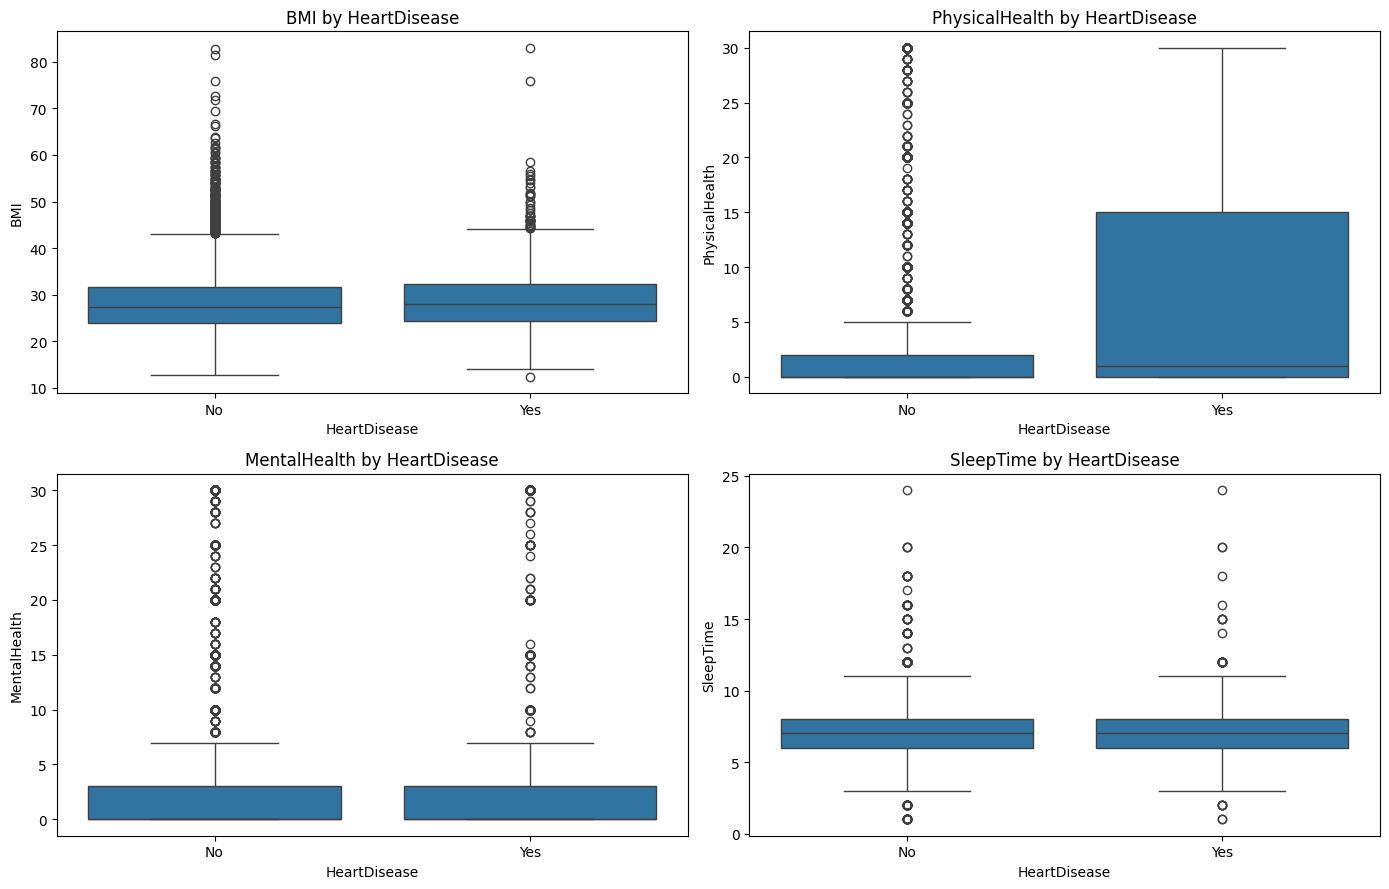

In [133]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for idx, col in enumerate(Numeric_cols):
    sns.boxplot(data=data, x=Target_col, y=col, ax=axes[idx])
    axes[idx].set_title(f'{col} by {Target_col}')

plt.tight_layout()
plt.show()

In [134]:
for col in Numeric_cols:
    median_no = data[data[Target_col] == 'No'][col].median()
    median_yes = data[data[Target_col] == 'Yes'][col].median()
    diff = abs(median_yes - median_no)
    
    print(f"{col}:")
    print(f" No:  {median_no:.2f}")
    print(f" Yes: {median_yes:.2f}")
    print(f"  Difference: {diff:.2f}")
    
    if diff > data[col].std() * 0.5:
        print(f"  Separation: Strong (predictive)")
    elif diff > data[col].std() * 0.3:
        print(f"  Separation: Moderate")
    else:
        print(f"  Separation: Weak (overlapping distributions)")
    print()

BMI:
 No:  27.34
 Yes: 27.98
  Difference: 0.64
  Separation: Weak (overlapping distributions)

PhysicalHealth:
 No:  0.00
 Yes: 1.00
  Difference: 1.00
  Separation: Weak (overlapping distributions)

MentalHealth:
 No:  0.00
 Yes: 0.00
  Difference: 0.00
  Separation: Weak (overlapping distributions)

SleepTime:
 No:  7.00
 Yes: 7.00
  Difference: 0.00
  Separation: Weak (overlapping distributions)



## Feature Importance Hypothesis (WITHOUT a Model)

Based only on visualization, classify features as:
- Strong candidate
- Medium importance
- Weak but keep
- Potentially removable (with caution)

Note: We are NOT allowed to remove features yet.

In [135]:
importance_table = pd.DataFrame([
    ['GenHealth', 'Large difference between Poor and Excellent', 'Strong'],
    ['AgeCategory', 'Clear increase in risk with age', 'Strong'],
    ['Smoking', 'Smokers show higher risk', 'Medium'],
    ['Diabetic', 'Diabetics show higher risk', 'Medium'],
    ['Sex', 'Males show higher risk', 'Medium'],
    ['BMI', 'Median shift visible', 'Medium'],
    ['PhysicalHealth', 'Some separation', 'Medium'],
    ['Race', 'Small differences between races', 'Weak'],
    ['SleepTime', 'Overlapping distributions', 'Weak'],
    ['MentalHealth', 'Limited separation', 'Weak'],
], columns=['Feature', 'Visual Evidence', 'Importance'])

print("Feature Importance Hypothesis (Based on Visualization):")
print(importance_table.to_string(index=False))


Feature Importance Hypothesis (Based on Visualization):
       Feature                             Visual Evidence Importance
     GenHealth Large difference between Poor and Excellent     Strong
   AgeCategory             Clear increase in risk with age     Strong
       Smoking                    Smokers show higher risk     Medium
      Diabetic                  Diabetics show higher risk     Medium
           Sex                      Males show higher risk     Medium
           BMI                        Median shift visible     Medium
PhysicalHealth                             Some separation     Medium
          Race             Small differences between races       Weak
     SleepTime                   Overlapping distributions       Weak
  MentalHealth                          Limited separation       Weak


In [136]:
# Feature Importance Hypothesis

In [137]:
print("Visualization Mistakes Check:\n")

mistakes = {
    "Used histogram for categorical data?": "NO",
    "Used pie chart for high-cardinality features?": "NO",
    "Compared numerical features with target using bar charts?": "NO",
    "Ignored class imbalance?": "NO",
}

for question, answer in mistakes.items():
    print(f"{question} {answer}")


Visualization Mistakes Check:

Used histogram for categorical data? NO
Used pie chart for high-cardinality features? NO
Compared numerical features with target using bar charts? NO
Ignored class imbalance? NO


---
# PART 3: Preprocessing & Encoding Decisions
---

## Handling Missing Values

**BMI (numerical):** Median imputation
- Why: Has outliers, median is robust
- Medical context: Extreme BMI values exist, median better represents typical patient

**SleepTime (numerical):** Median imputation
- Why: Median is more representative
- Medical context: Sleep patterns vary, median captures typical sleep duration

**SkinCancer (categorical):** Mode imputation
- Why: Most common value (No) is reasonable assumption
- Medical context: Skin cancer is less common, assuming "No" is safe

**DiffWalking (categorical):** Mode imputation
- Why: Most common value
- Medical context: Most people don't have walking difficulty

**Why not remove rows?**
In medical context, every patient record is valuable. Removing rows loses important data.

In [138]:
data_processed = data.copy()

if 'BMI' in data_processed.columns:
    data_processed['BMI'].fillna(data_processed['BMI'].median(), inplace=True)
    print("BMI: Filled with median")

if 'SleepTime' in data_processed.columns:
    data_processed['SleepTime'].fillna(data_processed['SleepTime'].median(), inplace=True)
    print("SleepTime: Filled with median")

if 'SkinCancer' in data_processed.columns:
    data_processed['SkinCancer'].fillna(data_processed['SkinCancer'].mode()[0], inplace=True)
    print("SkinCancer: Filled with mode")

if 'DiffWalking' in data_processed.columns:
    data_processed['DiffWalking'].fillna(data_processed['DiffWalking'].mode()[0], inplace=True)
    print("DiffWalking: Filled with mode")

print("\nMissing values after handling:", data_processed.isnull().sum().sum())

BMI: Filled with median
SleepTime: Filled with median
SkinCancer: Filled with mode
DiffWalking: Filled with mode

Missing values after handling: 0


## Feature Type Classification

Create a table with justifications:

| Feature | Type | Justification |
|---------|------|---------------|
| Smoking | Binary | Two values: Yes/No |
| AgeCategory | Ordinal categorical | Has clear ordering: 18-24 < 25-29 < ... < 80+ |
| GenHealth | Ordinal categorical | Has ordering: Poor < Fair < Good < Very good < Excellent |
| Race | Nominal categorical | No natural ordering between races |
| Diabetic | Nominal categorical | Multiple categories without order |
| BMI | Continuous numerical | Real numbers measuring body mass |
| PhysicalHealth | Continuous numerical | Count of days (0-30) |
| MentalHealth | Continuous numerical | Count of days (0-30) |
| SleepTime | Continuous numerical | Hours of sleep |

In [139]:
classification = pd.DataFrame([
    ['Smoking', 'Binary', 'Two values: Yes/No'],
    ['AlcoholDrinking', 'Binary', 'Two values: Yes/No'],
    ['Stroke', 'Binary', 'Two values: Yes/No'],
    ['DiffWalking', 'Binary', 'Two values: Yes/No'],
    ['Sex', 'Binary', 'Two values: Male/Female'],
    ['PhysicalActivity', 'Binary', 'Two values: Yes/No'],
    ['Asthma', 'Binary', 'Two values: Yes/No'],
    ['KidneyDisease', 'Binary', 'Two values: Yes/No'],
    ['SkinCancer', 'Binary', 'Two values: Yes/No'],
    ['AgeCategory', 'Ordinal categorical', 'Has ordering: 18-24 < 25-29 < ... < 80+'],
    ['GenHealth', 'Ordinal categorical', 'Has ordering: Poor < Fair < Good < Very good < Excellent'],
    ['Race', 'Nominal categorical', 'No natural ordering between races'],
    ['Diabetic', 'Nominal categorical', 'Multiple categories without order'],
    ['BMI', 'Continuous numerical', 'Real numbers measuring body mass'],
    ['PhysicalHealth', 'Continuous numerical', 'Count of days (0-30)'],
    ['MentalHealth', 'Continuous numerical', 'Count of days (0-30)'],
    ['SleepTime', 'Continuous numerical', 'Hours of sleep'],
], columns=['Feature', 'Type', 'Justification'])

print("Feature Type Classification:")
print(classification.to_string(index=False))

Feature Type Classification:
         Feature                 Type                                            Justification
         Smoking               Binary                                       Two values: Yes/No
 AlcoholDrinking               Binary                                       Two values: Yes/No
          Stroke               Binary                                       Two values: Yes/No
     DiffWalking               Binary                                       Two values: Yes/No
             Sex               Binary                                  Two values: Male/Female
PhysicalActivity               Binary                                       Two values: Yes/No
          Asthma               Binary                                       Two values: Yes/No
   KidneyDisease               Binary                                       Two values: Yes/No
      SkinCancer               Binary                                       Two values: Yes/No
     AgeCategory  Ord

## Encoding Strategy

For each categorical feature, choose ONE and justify:

### Binary Features: Label Encoding (0, 1)

**Why suitable:**
- Simple and efficient
- Preserves binary nature
- Doesn't increase dimensionality

**Why other options are risky:**
- One-Hot: Wastes space (creates 2 columns for 2 values)
- Manual Ordinal: Unnecessary for binary

### Ordinal Features: Manual Ordinal Encoding

**Why suitable:**
- Preserves the natural ordering
- Model understands Poor < Good < Excellent
- More informative than treating as nominal

**Why other options are risky:**
- Label Encoding: Random order (Poor=4, Excellent=1) loses meaning
- One-Hot: Loses ordering information completely

### Nominal Features: One-Hot Encoding

**Why suitable:**
- No false ordering created
- Each category treated independently
- Prevents model from assuming Race 1 < Race 2

**Why other options are risky:**
- Label Encoding: Creates false ordering (Asian=1, White=2 implies White > Asian)
- Manual Ordinal: Same problem - creates non-existent relationships

In [140]:
data_encoded = data_processed.copy()

# Binary encoding
for col in Binary_cols:
    le = LabelEncoder()
    data_encoded[col] = le.fit_transform(data_encoded[col])
print("Binary features encoded")

# Target encoding
le_target = LabelEncoder()
data_encoded[Target_col] = le_target.fit_transform(data_encoded[Target_col])
print("Target encoded")

# Ordinal encoding 
genhealth_mapping = {'Poor': 1, 'Fair': 2, 'Good': 3, 'Very good': 4, 'Excellent': 5}
data_encoded['GenHealth'] = data_encoded['GenHealth'].map(genhealth_mapping)

agecategory_mapping = {
    '18-24': 1, '25-29': 2, '30-34': 3, '35-39': 4, '40-44': 5, '45-49': 6,
    '50-54': 7, '55-59': 8, '60-64': 9, '65-69': 10, '70-74': 11, '75-79': 12,
    '80 or older': 13
}
data_encoded['AgeCategory'] = data_encoded['AgeCategory'].map(agecategory_mapping)
print("Ordinal features encoded")

# Nominal encoding 
for col in Nominal_cols:
    one_hot = pd.get_dummies(data_encoded[col], prefix=col, drop_first=True)
    data_encoded = pd.concat([data_encoded, one_hot], axis=1)
    data_encoded.drop(col, axis=1, inplace=True)
print("Nominal features encoded")

print(f"\nColumns after encoding: {data_encoded.shape[1]}")

Binary features encoded
Target encoded
Ordinal features encoded
Nominal features encoded

Columns after encoding: 24


---
# PART 4: Splitting, Scaling & Leakage Awareness
---

## Data Splitting - Class Distribution Challenge

**Requirement:** Every class in HeartDisease must appear in BOTH train and test sets.

**Q: Choose - Random split, Stratified split, K-Fold, or Stratified K-Fold?**
  - Stratified split

**Which guarantees the requirement?**
- Stratified split: YES - maintains class proportions
- Stratified K-Fold: YES - but used for cross-validation, not single split

**Why might another method fail?**
- Random split: With 90% No and 10% Yes, random split might put all Yes in train or all in test
- K-Fold: Same problem - no guarantee of class representation in each fold

In [141]:
X = data_encoded.drop(Target_col, axis=1)
y = data_encoded[Target_col]

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y )

print(f"Train: {X_train.shape[0]} samples")
print(f"Test: {X_test.shape[0]} samples")

print("\nTrain distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest distribution:")
print(y_test.value_counts(normalize=True) * 100)


Train: 13487 samples
Test: 3372 samples

Train distribution:
HeartDisease
0    90.190554
1     9.809446
Name: proportion, dtype: float64

Test distribution:
HeartDisease
0    90.183867
1     9.816133
Name: proportion, dtype: float64


## Data Leakage Awareness

**Q: Decide the correct order for: Splitting, Encoding, Scaling** 
1. Encoding (can be done before or after split)
2. Splitting
3. Scaling

**Which orders cause data leakage?**

Wrong order:
1. Scale 
2. Split

Why wrong: Scaler sees test data statistics (mean, std) during fitting.

CORRECT order:
1. Split
2. Scale (fit ONLY on train)
3. Transform both train and test

**Why is leakage especially dangerous in healthcare ML?**

- Model appears to perform well in development
- Fails catastrophically with real new patients
- Can lead to wrong medical decisions
- Patient safety is at risk
- Test set represents future unseen patients - they should be completely isolated

In [142]:
print("Data Leakage Prevention:")
print("\nCorrect order:")
print("1. Split the data")
print("2. Fit scaler on TRAIN only")
print("3. Transform both train and test using fitted scaler")
print("\nThis ensures test data is never seen during preprocessing")

Data Leakage Prevention:

Correct order:
1. Split the data
2. Fit scaler on TRAIN only
3. Transform both train and test using fitted scaler

This ensures test data is never seen during preprocessing


## Scaling Strategy

Numerical features: BMI, PhysicalHealth, MentalHealth, SleepTime

**Q: Choose ONE - StandardScaler, MinMaxScaler, RobustScaler, or No scaling?**
 - RobustScaler

**Justify based on:**

1. **Outliers:** 
   - RobustScaler uses median and IQR, resistant to outliers
   - StandardScaler uses mean and std, sensitive to outliers

2. **Medical meaning:** Extreme values in medical data are often real, not errors
   - Very high BMI or many sick days are valid patient conditions
   - RobustScaler handles these without distortion

3. **Model sensitivity:** Tree-based models don't need scaling, but if we use SVM/Neural Networks:
   - Robust scaling ensures features contribute fairly
   - Prevents outliers from dominating

**Q: Should encoded categorical features be scaled? Why?**
   - No

In [143]:
cols_to_scale = Numeric_cols + Ordinal_cols

scaler = RobustScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print(f"Scaled columns: {cols_to_scale}")

Scaled columns: ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime', 'GenHealth', 'AgeCategory']


## Final Pipeline Construction

**Q: Choose ONE approach - Manual preprocessing, ColumnTransformer, or Pipeline?**
   - Pipeline

**Justify:**

**Why Pipeline:**
- Organized: All steps in one place
- Safe: Prevents data leakage automatically
- Reusable: Easy to apply to new data
- Production-ready: Can be saved and deployed

**Why not Manual:**
- Error-prone: Easy to forget steps
- Leakage risk: Might accidentally fit on test data
- Hard to maintain: Changes require updating multiple places

In [144]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), Numeric_cols),
        ('ord', RobustScaler(), Ordinal_cols),
    ],
    remainder='passthrough'
)

print("ColumnTransformer created:")
print("- RobustScaler for numerical features")
print("- RobustScaler for ordinal features")
print("- Passthrough for binary and one-hot features")

ColumnTransformer created:
- RobustScaler for numerical features
- RobustScaler for ordinal features
- Passthrough for binary and one-hot features


Final

In [145]:
print("Final Statistics:")
print(f"Total samples: {len(data)}")
print(f"Original columns: {data.shape[1]}")
print(f"Encoded columns: {X.shape[1]}")
print(f"Train: {X_train_scaled.shape}")
print(f"Test: {X_test_scaled.shape}")

Final Statistics:
Total samples: 16859
Original columns: 18
Encoded columns: 23
Train: (13487, 23)
Test: (3372, 23)
